<a href="https://colab.research.google.com/github/sahithkumar1999/MyProjects/blob/ml-project/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!python -m pip install -r /content/drive/MyDrive/DATA/requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 27.4 MB/s eta 0:00:00


In [ ]:
!pip install cudf-cu11 cuml-cu11 --extra-index-url=https://pypi.nvidia.com


Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 49.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 77.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 427.5/427.5 MB 40.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 114.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.4/26.4 MB 198.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 203.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 224.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.9/30.9 MB 203.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 213.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 76.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
!pip install --upgrade cupy-cuda12x
!pip install --upgrade rmm
!pip install --extra-index-url=https://pypi.nvidia.com cudf-cu12 cuml-cu12


In [ ]:
!pip uninstall -y cupy-cuda11x cupy-cuda12x cupy cupy-cuda-runtime
!pip uninstall -y rmm cudf cuml
!pip install --extra-index-url=https://pypi.nvidia.com cupy-cuda12x
!pip install --extra-index-url=https://pypi.nvidia.com cudf-cu12 cuml-cu12 rmm


In [ ]:
import numpy as np
import pandas as pd
import glob
import os
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import GPU-accelerated CuML RandomForest
from cuml.ensemble import RandomForestRegressor  # GPU version of RF
import cupy as cp  # GPU-compatible NumPy replacement
from sklearn.inspection import permutation_importance

class TreeModel:

    def __init__(self, dataset_path):
        # Read the CSV file
        dataframe = pd.read_csv(dataset_path[0], header=0)

        # Use the second column (index 1) as target variable (distance in cm)
        self.labels = dataframe.iloc[:, 1].values.astype(float)
        # Use columns from the 6th column onward (index 5) as features
        self.features = dataframe.iloc[:, 5:]

        # Create a scaler for feature normalization
        self.scaler = MinMaxScaler()

        print("Input data shape (raw features):", self.features.shape)

    def preprocess(self):
        processed_features = []
        for i in range(len(self.features)):
            # Get the signal values as a float numpy array
            signal = self.features.iloc[i, :].values.astype(float)
            n = len(signal)
            dt = 1e-6

            # Apply a Hamming window
            signal_windowed = signal * np.hamming(n)

            # Compute FFT and Power Spectral Density (PSD)
            fhat = np.fft.fft(signal_windowed, n)
            PSD = np.abs(fhat) ** 2 / n
            freqs = np.fft.fftfreq(n, d=dt)

            # Filter frequencies between 30 kHz and 50 kHz
            mask = (freqs > 30e3) & (freqs < 50e3)
            PSD_filtered = PSD[mask]

            # Append processed PSD
            processed_features.append(PSD_filtered)

        # Convert to DataFrame and normalize
        processed_features = pd.DataFrame(processed_features)
        processed_features = self.scaler.fit_transform(processed_features)

        print("Processed features shape before feature selection:", processed_features.shape)

        return processed_features

    def feature_selection(self, x_train, y_train):
      print("Performing feature selection using GPU-based RandomForest...")

      # Train GPU-based RandomForest
      rf = RandomForestRegressor(n_estimators=100, random_state=42, n_streams=1)
      rf.fit(cp.asarray(x_train), cp.asarray(y_train))

      print("Computing feature importance using Permutation Feature Importance (PFI)...")

      # Convert data back to NumPy for permutation importance calculation
      x_train_np = cp.asnumpy(x_train)
      y_train_np = cp.asnumpy(y_train)

      # Compute feature importance using permutation importance (runs on CPU)
      pfi_result = permutation_importance(rf, x_train_np, y_train_np, n_repeats=5, random_state=42, n_jobs=-1)

      # Get importance scores
      feature_importances = pfi_result.importances_mean

      # Select top 100 features
      top_features = np.argsort(feature_importances)[-500:]

      print("Selected top 100 features shape:", x_train[:, top_features].shape)

      return top_features


    def train_and_evaluate(self, x_train, x_val, x_test, y_train, y_val, y_test):
      selected_features = self.feature_selection(x_train, y_train)

      # Apply selected features to datasets
      x_train = x_train[:, selected_features]
      x_val = x_val[:, selected_features]
      x_test = x_test[:, selected_features]

      # Convert CuPy arrays to NumPy before passing to Scikit-learn
      x_train_np = x_train.get()
      y_train_np = y_train.get()
      x_val_np = x_val.get()
      x_test_np = x_test.get()
      y_val_np = y_val.get()
      y_test_np = y_test.get()

      # Hyperparameter tuning using RandomizedSearchCV
      param_dist = {
          'n_estimators': [500, 700, 1000],
          'max_depth': [30, 50, None],
          'min_samples_split': [2, 5],
          'min_samples_leaf': [1, 2]
      }

      print("Performing hyperparameter tuning with GPU...")
      rf_model = RandomForestRegressor(random_state=42)

      random_search = RandomizedSearchCV(
          rf_model, param_distributions=param_dist, n_iter=20, cv=3,
          n_jobs=-1, verbose=2, scoring='neg_mean_absolute_error'
      )

      random_search.fit(x_train_np, y_train_np)  # Now using NumPy arrays

      best_rf_model = random_search.best_estimator_

      # Save best model as a pickle file
      model_save_path_rf = "/content/drive/MyDrive/DATA/SavedModels/random_forest_best_model.pkl"
      os.makedirs(os.path.dirname(model_save_path_rf), exist_ok=True)
      joblib.dump(best_rf_model, model_save_path_rf)

      print(f"Best Random Forest model saved at: {model_save_path_rf}")

      # Predict on test set
      predictions_rf = best_rf_model.predict(x_test_np)

      # Evaluate Random Forest
      mae_rf = mean_absolute_error(y_test_np, predictions_rf)
      mse_rf = mean_squared_error(y_test_np, predictions_rf)
      rmse_rf = np.sqrt(mse_rf)
      r2_rf = r2_score(y_test_np, predictions_rf)

      print(f"Random Forest - MAE: {mae_rf:.2f} cm, MSE: {mse_rf:.2f} cm^2, RMSE: {rmse_rf:.2f} cm, R²: {r2_rf:.2f}")

      return best_rf_model


def main():
    dataset = glob.glob(r'/content/drive/MyDrive/DATA/DataMerge.csv')
    print('Reading dataset: ', dataset)

    obj = TreeModel(dataset)

    print("Preprocessing data...")
    x_data = obj.preprocess()
    y_data = obj.labels

    # Convert to CuPy arrays for GPU acceleration
    x_data = cp.asarray(x_data)
    y_data = cp.asarray(y_data)

    # Split data into 60% train, 20% validation, and 20% test sets
    x_train, x_temp, y_train, y_temp = train_test_split(x_data, y_data,
                                                        train_size=0.6,
                                                        random_state=42)

    x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp,
                                                    test_size=0.5,
                                                    random_state=42)

    print(f"Train set: {x_train.shape[0]} samples")
    print(f"Validation set: {x_val.shape[0]} samples")
    print(f"Test set: {x_test.shape[0]} samples")

    print("Training and evaluating models...")
    best_rf_model = obj.train_and_evaluate(x_train, x_val, x_test, y_train, y_val, y_test)

    # Save the scaler for future use
    joblib.dump(obj.scaler, "SavedModels/feature_scaler.pkl")


if __name__ == "__main__":
    main()


Reading dataset:  ['/content/drive/MyDrive/DATA/DataMerge.csv']


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
import numpy as np
import pandas as pd
import glob
import os
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# GPU-accelerated CuML RandomForest
from cuml.ensemble import RandomForestRegressor  # GPU version of RF
import cupy as cp  # GPU-compatible NumPy replacement

# Scikit-learn RandomForest (for CPU)
from sklearn.ensemble import RandomForestRegressor as SKRandomForestRegressor
from sklearn.inspection import permutation_importance

from sklearn.ensemble import RandomForestRegressor as SKRandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV


class TreeModel:

    def __init__(self, dataset_path):
        # Read the CSV file
        dataframe = pd.read_csv(dataset_path[0], header=0)

        # Use the second column (index 1) as target variable (distance in cm)
        self.labels = dataframe.iloc[:, 1].values.astype(float)
        # Use columns from the 6th column onward (index 5) as features
        self.features = dataframe.iloc[:, 5:]

        # Create a scaler for feature normalization
        self.scaler = MinMaxScaler()

        print("Input data shape (raw features):", self.features.shape)

    def preprocess(self):
        processed_features = []

        for i in range(len(self.features)):
            # Get the signal values as a float numpy array
            signal = self.features.iloc[i, :].values.astype(float)
            n = len(signal)
            dt = 1e-6

            # Apply a Hamming window
            signal_windowed = signal * np.hamming(n)

            # Compute FFT and Power Spectral Density (PSD)
            fhat = np.fft.fft(signal_windowed, n)
            PSD = np.abs(fhat) ** 2 / n
            freqs = np.fft.fftfreq(n, d=dt)

            # Filter frequencies between 30 kHz and 50 kHz
            mask = (freqs > 30e3) & (freqs < 50e3)
            PSD_filtered = PSD[mask]

            # Append processed PSD
            processed_features.append(PSD_filtered)

        # Convert to DataFrame and normalize
        processed_features = pd.DataFrame(processed_features)
        processed_features = self.scaler.fit_transform(processed_features)

        print("Processed features shape before feature selection:", processed_features.shape)
        return processed_features

    def feature_selection(self, x_train, y_train):
        print("Performing feature selection using GPU-based RandomForest...")

        # Train GPU-based RandomForest
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_streams=1)
        rf.fit(cp.asarray(x_train), cp.asarray(y_train))

        print("Computing feature importance using Permutation Feature Importance (PFI)...")

        # Convert data back to NumPy for permutation importance calculation
        x_train_np = cp.asnumpy(x_train)
        y_train_np = cp.asnumpy(y_train)

        # Compute feature importance using permutation importance (runs on CPU)
        pfi_result = permutation_importance(rf, x_train_np, y_train_np, n_repeats=5, random_state=42, n_jobs=-1)

        # Get importance scores
        feature_importances = pfi_result.importances_mean

        # Select top 500 features
        top_features = np.argsort(feature_importances)[-500:]

        print("Selected top 500 features shape:", x_train[:, top_features].shape)

        return top_features

    def convert_cuml_to_sklearn(self, cuml_model, x_train, y_train):
        """Convert CuML RandomForestRegressor to Scikit-Learn RandomForestRegressor"""
        sklearn_model = SKRandomForestRegressor(
            n_estimators=cuml_model.n_estimators,
            max_depth=cuml_model.max_depth,
            min_samples_split=cuml_model.min_samples_split,
            min_samples_leaf=cuml_model.min_samples_leaf,
            random_state=42
        )

        # Train the Scikit-Learn model on the same dataset
        sklearn_model.fit(x_train, y_train)
        return sklearn_model

    def train_and_evaluate(self, x_train, x_val, x_test, y_train, y_val, y_test):
      selected_features = self.feature_selection(x_train, y_train)

      # Apply selected features to datasets
      x_train = x_train[:, selected_features]
      x_val = x_val[:, selected_features]
      x_test = x_test[:, selected_features]

      # Convert CuPy arrays to NumPy before passing to Scikit-learn
      x_train_np = x_train.get()
      y_train_np = y_train.get()
      x_val_np = x_val.get()
      x_test_np = x_test.get()
      y_val_np = y_val.get()
      y_test_np = y_test.get()

      print("Training CuML RandomForestRegressor on GPU...")
      rf_cuml = RandomForestRegressor(n_estimators=100, random_state=42, n_streams=1)
      rf_cuml.fit(cp.asarray(x_train), cp.asarray(y_train))

      print("Converting trained CuML model to Scikit-Learn RandomForestRegressor...")
      rf_sklearn = SKRandomForestRegressor(
          n_estimators=rf_cuml.n_estimators,
          max_depth=rf_cuml.max_depth,
          min_samples_split=2,
          min_samples_leaf=1,
          random_state=42
      )

      # Re-train the Scikit-Learn model on the same dataset
      rf_sklearn.fit(x_train_np, y_train_np)

      print("Performing hyperparameter tuning using Scikit-Learn...")
      param_dist = {
          'n_estimators': [500, 700, 1000],
          'max_depth': [30, 50, None],
          'min_samples_split': [2, 5],
          'min_samples_leaf': [1, 2]
      }

      random_search = RandomizedSearchCV(
          rf_sklearn, param_distributions=param_dist, n_iter=10, cv=3,
          n_jobs=-1, verbose=2, scoring='neg_mean_absolute_error'
      )

      random_search.fit(x_train_np, y_train_np)  # Using NumPy arrays

      best_rf_model = random_search.best_estimator_

      # Save the Scikit-Learn model (NOT CuML) for compatibility
      model_save_path_rf = "/content/drive/MyDrive/DATA/SavedModels/random_forest_best_modelfinal5.pkl"
      scaler_save_path = "/content/drive/MyDrive/DATA/SavedModels/feature_scaler.pkl"  # Save the scaler
      os.makedirs(os.path.dirname(model_save_path_rf), exist_ok=True)
      os.makedirs(os.path.dirname(scaler_save_path), exist_ok=True)
      joblib.dump(best_rf_model, model_save_path_rf)

      joblib.dump(self.scaler, scaler_save_path)

      print(f"Best Random Forest model saved at: {model_save_path_rf}")
      print(f"✅ Feature scaler saved at: {scaler_save_path}")

      # Predict on test set
      predictions_rf = best_rf_model.predict(x_test_np)

      # Evaluate Random Forest
      mae_rf = mean_absolute_error(y_test_np, predictions_rf)
      mse_rf = mean_squared_error(y_test_np, predictions_rf)
      rmse_rf = np.sqrt(mse_rf)
      r2_rf = r2_score(y_test_np, predictions_rf)

      print(f"Random Forest - MAE: {mae_rf:.2f} cm, MSE: {mse_rf:.2f} cm^2, RMSE: {rmse_rf:.2f} cm, R²: {r2_rf:.2f}")

      return best_rf_model


def main():
    dataset = glob.glob(r'/content/drive/MyDrive/DATA/DataMerge.csv')
    print('Reading dataset:', dataset)

    obj = TreeModel(dataset)

    print("Preprocessing data...")
    x_data = obj.preprocess()
    y_data = obj.labels

    x_data = cp.asarray(x_data)
    y_data = cp.asarray(y_data)

    x_train, x_temp, y_train, y_temp = train_test_split(x_data, y_data, train_size=0.6, random_state=42)
    x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

    best_rf_model = obj.train_and_evaluate(x_train, x_val, x_test, y_train, y_val, y_test)


if __name__ == "__main__":
    main()


Reading dataset: ['/content/drive/MyDrive/DATA/DataMerge.csv']
Input data shape (raw features): (30999, 24997)
Preprocessing data...
Processed features shape before feature selection: (30999, 500)
Performing feature selection using GPU-based RandomForest...
Computing feature importance using Permutation Feature Importance (PFI)...
Selected top 500 features shape: (18599, 500)
Training CuML RandomForestRegressor on GPU...
Converting trained CuML model to Scikit-Learn RandomForestRegressor...
Performing hyperparameter tuning using Scikit-Learn...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Random Forest model saved at: SavedModels/random_forest_best_modelfinal5.pkl
Random Forest - MAE: 5.12 cm, MSE: 154.51 cm^2, RMSE: 12.43 cm, R²: 0.95


# Classification

Improved CNN + BiLSTM Hybrid Model

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization,
                                     LSTM, Bidirectional, Input, Add)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

class ImprovedCNNModel():
    def __init__(self, dataset_path):
        dataframe = pd.read_csv(dataset_path[0], delimiter=',', encoding='utf-8')
        self.labels = dataframe.iloc[:, 0]
        self.features = dataframe.iloc[:, 2:]
        self.scaler = StandardScaler()

    def preprocess(self):
        processed_features = []
        for i in range(len(self.features)):
            signal = self.features.iloc[i, :].values
            n = len(signal)
            dt = 1e-6
            signal = signal * np.hamming(n)
            fhat = np.fft.fft(signal, n)
            PSD = np.abs(fhat) ** 2 / n
            freqs = np.fft.fftfreq(n, d=dt)
            mask = (freqs > 30e3) & (freqs < 50e3)
            PSD_filtered = PSD[mask]
            processed_features.append(PSD_filtered)

        processed_features = self.scaler.fit_transform(pd.DataFrame(processed_features))
        self.processed_features = processed_features.reshape(processed_features.shape[0], processed_features.shape[1], 1)
        return self.processed_features

    def build_optimized_model(self, input_shape):
        inputs = Input(shape=input_shape)

        # First Conv Block
        x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
        x = BatchNormalization()(x)
        x = MaxPooling1D(pool_size=2)(x)
        x = Dropout(0.3)(x)

        # Second Conv Block
        x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = MaxPooling1D(pool_size=2)(x)
        x = Dropout(0.3)(x)

        # Residual Block (Skip Connection)
        x_residual = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
        x_residual = BatchNormalization()(x_residual)
        x = Add()([x, x_residual])  # Skip Connection
        x = Dropout(0.3)(x)

        # Third Conv Block
        x = Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = MaxPooling1D(pool_size=2)(x)
        x = Dropout(0.3)(x)

        # BiLSTM Layer
        x = Bidirectional(LSTM(128, return_sequences=True))(x)
        x = Bidirectional(LSTM(64))(x)

        # Fully Connected Layers
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.4)(x)
        x = Dense(64, activation='relu')(x)
        x = Dropout(0.4)(x)

        # Output Layer
        outputs = Dense(1, activation='sigmoid')(x)

        # Build & Compile Model
        model = Model(inputs, outputs)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss='binary_crossentropy', metrics=['accuracy'])
        return model

    def train_and_evaluate(self, xtrain, xtest, ytrain, ytest):
        model = self.build_optimized_model(xtrain.shape[1:])

        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

        model.fit(xtrain, ytrain, epochs=100, batch_size=32, validation_split=0.2,
                  callbacks=[early_stop, reduce_lr])

        model.save("/content/drive/MyDrive/DATA/SavedModels/optimized_cnn_model.h5")

        predictions = (model.predict(xtest) > 0.5).astype("int32")
        cm = tf.math.confusion_matrix(ytest, predictions)

        accuracy = np.sum(np.diag(cm)) / np.sum(cm)
        print(f"Overall Accuracy: {accuracy * 100:.2f}%")
        return cm

# --- Main Script ---
def main():
    dataset = ['/content/drive/MyDrive/DATA/DataMerge.csv']
    obj = ImprovedCNNModel(dataset)

    print("Preprocessing data...")
    x_data = obj.preprocess()
    label_encoder = LabelEncoder()
    y_data = label_encoder.fit_transform(obj.labels)

    print("Splitting data into train and test...")
    xtrain, xtest, ytrain, ytest = train_test_split(x_data, y_data, test_size=0.25, random_state=42)

    print("Training and evaluating model...")
    cm = obj.train_and_evaluate(xtrain, xtest, ytrain, ytest)
    print("Confusion matrix:\n", cm.numpy())

if __name__ == "__main__":
    main()


Preprocessing data...
Splitting data into train and test...
Training and evaluating model...
Epoch 1/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 124s 198ms/step - accuracy: 0.9383 - loss: 0.1620 - val_accuracy: 0.7065 - val_loss: 1.0814 - learning_rate: 0.0010
Epoch 2/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 103s 176ms/step - accuracy: 0.9849 - loss: 0.0550 - val_accuracy: 0.7267 - val_loss: 0.8257 - learning_rate: 0.0010
Epoch 3/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 102s 175ms/step - accuracy: 0.9893 - loss: 0.0458 - val_accuracy: 0.9738 - val_loss: 0.0614 - learning_rate: 0.0010
Epoch 4/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 103s 176ms/step - accuracy: 0.9888 - loss: 0.0473 - val_accuracy: 0.8553 - val_loss: 0.2931 - learning_rate: 0.0010
Epoch 5/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 96s 165ms/step - accuracy: 0.9861 - loss: 0.0501 - val_accuracy: 0.8052 - val_loss: 1.9073 - learning_rate: 0.0010
Epoch 6/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 99s 170ms/step - accuracy: 0.9880 - loss: 0.0468 - val_accuracy: 0.9798 - val_loss

243/243 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step
Overall Accuracy: 99.82%
Confusion matrix:
 [[2490   10]
 [   4 5246]]


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization,
                                     LSTM, Bidirectional, Input, Add)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

class ImprovedCNNModel():
    def __init__(self, dataset_path):
        print("\nLoading dataset...")

        dataframe = pd.read_csv(dataset_path[0], delimiter=',', encoding='utf-8')

        print("\nDataset loaded successfully!")
        print(f"Dataset Shape: {dataframe.shape}")
        print(f"Column Names: {dataframe.columns.tolist()}")

        self.labels = dataframe.iloc[:, 0]
        self.features = dataframe.iloc[:, 2:]

        print(f"\nFeature Data Shape: {self.features.shape}")
        print(f"Label Data Shape: {self.labels.shape}")

        self.scaler = StandardScaler()

    def preprocess(self):
        print("\nStarting preprocessing...")

        processed_features = []

        for i in range(len(self.features)):
            signal = self.features.iloc[i, :].values
            n = len(signal)
            dt = 1e-6  # Assume sampling rate 1 MHz

            signal = signal * np.hamming(n)  # Apply Hamming window
            fhat = np.fft.fft(signal, n)  # FFT transform
            PSD = np.abs(fhat) ** 2 / n  # Power Spectral Density (PSD)
            freqs = np.fft.fftfreq(n, d=dt)

            # Extract frequencies between 30-50 kHz
            mask = (freqs > 30e3) & (freqs < 50e3)
            PSD_filtered = PSD[mask]

            processed_features.append(PSD_filtered)

        # Convert to DataFrame & Standardize
        processed_features = self.scaler.fit_transform(pd.DataFrame(processed_features))
        self.processed_features = processed_features.reshape(processed_features.shape[0], processed_features.shape[1], 1)

        print(f"\nProcessed Features Shape: {self.processed_features.shape}")
        return self.processed_features

    def build_optimized_model(self, input_shape):
        print("\nBuilding optimized CNN-LSTM model...")

        inputs = Input(shape=input_shape)

        # First Conv Block
        x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
        x = BatchNormalization()(x)
        x = MaxPooling1D(pool_size=2)(x)
        x = Dropout(0.3)(x)

        # Second Conv Block
        x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = MaxPooling1D(pool_size=2)(x)
        x = Dropout(0.3)(x)

        # Residual Block (Skip Connection)
        x_residual = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
        x_residual = BatchNormalization()(x_residual)
        x = Add()([x, x_residual])  # Skip Connection
        x = Dropout(0.3)(x)

        # Third Conv Block
        x = Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = MaxPooling1D(pool_size=2)(x)
        x = Dropout(0.3)(x)

        # BiLSTM Layer
        x = Bidirectional(LSTM(128, return_sequences=True))(x)
        x = Bidirectional(LSTM(64))(x)

        # Fully Connected Layers
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.4)(x)
        x = Dense(64, activation='relu')(x)
        x = Dropout(0.4)(x)

        # Output Layer
        outputs = Dense(1, activation='sigmoid')(x)

        # Build & Compile Model
        model = Model(inputs, outputs)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss='binary_crossentropy', metrics=['accuracy'])

        print("\nModel Architecture Summary:")
        model.summary()  # Print model architecture

        return model

    def train_and_evaluate(self, xtrain, xtest, ytrain, ytest):
        print("\nTraining Model...")

        model = self.build_optimized_model(xtrain.shape[1:])

        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

        history = model.fit(xtrain, ytrain, epochs=100, batch_size=32, validation_split=0.2,
                            callbacks=[early_stop, reduce_lr])

        model.save("/content/drive/MyDrive/DATA/SavedModels/optimized_cnn_modelwithALLData.keras")
        print("\nModel saved successfully!")

        # Evaluate Model
        print("\nEvaluating Model...")
        predictions = (model.predict(xtest) > 0.5).astype("int32")
        cm = tf.math.confusion_matrix(ytest, predictions)

        accuracy = np.sum(np.diag(cm)) / np.sum(cm)
        print(f"\nOverall Accuracy: {accuracy * 100:.2f}%")

        print("\nConfusion Matrix:")
        print(cm.numpy())

        return cm


# --- Main Script ---
def main():
    dataset = ['/content/drive/MyDrive/DATA/DataMergeALL.csv']
    print(f"\nUsing dataset: {dataset[0]}")

    obj = ImprovedCNNModel(dataset)

    print("\nStarting data preprocessing...")
    x_data = obj.preprocess()

    label_encoder = LabelEncoder()
    y_data = label_encoder.fit_transform(obj.labels)

    print(f"\nEncoded Labels Shape: {y_data.shape}")
    print(f"Number of Classes: {len(np.unique(y_data))}")

    print("\nSplitting data into training and testing sets...")
    xtrain, xtest, ytrain, ytest = train_test_split(x_data, y_data, test_size=0.25, random_state=42)

    print(f"\nTraining Data Shape: {xtrain.shape}, Labels: {ytrain.shape}")
    print(f"Testing Data Shape: {xtest.shape}, Labels: {ytest.shape}")

    print("\nTraining and evaluating the model...")
    cm = obj.train_and_evaluate(xtrain, xtest, ytrain, ytest)

    print("\nFinal Confusion Matrix:")
    print(cm.numpy())

if __name__ == "__main__":
    main()



Using dataset: /content/drive/MyDrive/DATA/DataMergeALL.csv

Loading dataset...

Dataset loaded successfully!
Dataset Shape: (89999, 25019)
Column Names: ['Human', '42.5', '68.0', '50000.0', '0.0', '1.0', '512.0', '1.0.1', '1953125.0', '14.0', '15.0', '2622.0', '3.602227210998535', '0.0.1', '0.0.2', '2.0', '1.0.2', '0.0.3', '26308.96875', '-55.0', '-57.0', '-55.0.1', '-60.0', '-60.0.1', '-59.0', '-62.0', '-63.0', '-65.0', '-63.0.1', '-60.0.2', '-63.0.2', '-61.0', '-59.0.1', '-60.0.3', '-62.0.1', '-67.0', '-70.0', '-75.0', '-76.0', '-80.0', '-83.0', '-81.0', '-80.0.1', '-80.0.2', '-78.0', '-76.0.1', '-70.0.1', '-67.0.1', '-69.0', '-71.0', '-73.0', '-75.0.1', '-70.0.2', '-66.0', '-68.0', '-68.0.1', '-67.0.2', '-65.0.1', '-60.0.4', '-59.0.2', '-60.0.5', '-55.0.2', '-52.0', '-50.0', '-52.0.1', '-54.0', '-56.0', '-51.0', '-49.0', '-52.0.2', '-52.0.3', '-54.0.1', '-57.0.1', '-58.0', '-58.0.1', '-60.0.6', '-57.0.2', '-59.0.3', '-61.0.1', '-65.0.2', '-69.0.1', '-69.0.2', '-70.0.3', '-71.0.1',

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 500, 1)         │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 500, 64)        │            256 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 500, 64)        │            256 │ conv1d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d             │ (None, 250, 64)        │              0 │ batch_normalization[0… │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 250, 64)        │              0 │ max_pooling1d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 250, 128)       │         24,704 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 250, 128)       │            512 │ conv1d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_1           │ (None, 125, 128)       │              0 │ batch_normalization_1… │
│ (MaxPooling1D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 125, 128)       │              0 │ max_pooling1d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_2 (Conv1D)         │ (None, 125, 128)       │         49,280 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 125, 128)       │            512 │ conv1d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 125, 128)       │              0 │ dropout_1[0][0],       │
│                           │                        │                │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 125, 128)       │              0 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_3 (Conv1D)         │ (None, 125, 256)       │         98,560 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 125, 256)       │          1,024 │ conv1d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling1d_2           │ (None, 62, 256)        │              0 │ batch_normalization_3… │
│ (MaxPooling1D)       

 Total params: 758,529 (2.89 MB)

 Trainable params: 757,377 (2.89 MB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 53s 24ms/step - accuracy: 0.3322 - loss: nan - val_accuracy: 0.3430 - val_loss: nan - learning_rate: 0.0010
Epoch 2/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.3350 - loss: nan - val_accuracy: 0.3430 - val_loss: nan - learning_rate: 0.0010
Epoch 3/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.3327 - loss: nan - val_accuracy: 0.3430 - val_loss: nan - learning_rate: 0.0010
Epoch 4/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.3342 - loss: nan - val_accuracy: 0.3430 - val_loss: nan - learning_rate: 0.0010
Epoch 5/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.3332 - loss: nan - val_accuracy: 0.3430 - val_loss: nan - learning_rate: 0.0010
Epoch 6/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.3284 - loss: nan - val_accuracy: 0.3430 - val_loss: nan - learning_rate: 5.0000e-04
Epoch 7/100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.3281 - loss: nan - 

In [ ]:
import numpy as np
import pandas as pd
import glob
import os
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Scikit-learn KNN Regressor (for CPU compatibility)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import SelectKBest, f_regression

class KNNModel:
    def __init__(self, dataset_path):
        # Read the CSV file
        dataframe = pd.read_csv(dataset_path[0], header=0)

        # Use the second column (index 1) as target variable (distance in cm)
        self.labels = dataframe.iloc[:, 1].values.astype(float)
        # Use columns from the 6th column onward (index 5) as features
        self.features = dataframe.iloc[:, 5:]

        # Create a scaler for feature normalization
        self.scaler = MinMaxScaler()

        print("Input data shape (raw features):", self.features.shape)

    def preprocess(self):
        processed_features = []
        for i in range(len(self.features)):
            # Get the signal values as a float numpy array
            signal = self.features.iloc[i, :].values.astype(float)
            n = len(signal)
            dt = 1e-6

            # Apply a Hamming window
            signal_windowed = signal * np.hamming(n)

            # Compute FFT and Power Spectral Density (PSD)
            fhat = np.fft.fft(signal_windowed, n)
            PSD = np.abs(fhat) ** 2 / n
            freqs = np.fft.fftfreq(n, d=dt)

            # Filter frequencies between 30 kHz and 50 kHz
            mask = (freqs > 30e3) & (freqs < 50e3)
            PSD_filtered = PSD[mask]

            # Append processed PSD
            processed_features.append(PSD_filtered)

        # Convert to DataFrame and normalize
        processed_features = pd.DataFrame(processed_features)
        processed_features = self.scaler.fit_transform(processed_features)

        print("Processed features shape before selection:", processed_features.shape)
        return processed_features

    def feature_selection(self, x_train, y_train):
        print("Selecting top 1000 features using KBest...")
        selector = SelectKBest(score_func=f_regression, k=1000)
        x_train_selected = selector.fit_transform(x_train, y_train)
        print("Selected top 1000 features shape:", x_train_selected.shape)
        return selector

    def build_knn_network(self, input_shape):
        model = Sequential([
            Dense(1024, activation='relu', input_shape=(input_shape,)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(512, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(256, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(128, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(64, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(32, activation='relu'),
            BatchNormalization(),
            Dense(1, activation='linear')
        ])
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model

    def train_and_evaluate(self, x_train, x_val, x_test, y_train, y_val, y_test):
        selector = self.feature_selection(x_train, y_train)
        x_train = selector.transform(x_train)
        x_val = selector.transform(x_val)
        x_test = selector.transform(x_test)

        print("Training Deep Neural Network with KNN features...")
        model = self.build_knn_network(x_train.shape[1])
        model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=100, batch_size=32, verbose=1)

        model_save_path = "/content/drive/MyDrive/DATA/SavedModels/knn_dnn_model.keras"
        model.save(model_save_path, save_format="keras")
        print(f"Neural Network model saved at: {model_save_path}")

        # Predict on test set
        predictions = model.predict(x_test)

        # Save actual vs predicted values
        results_df = pd.DataFrame({'Actual': y_test, 'Predicted': predictions.flatten()})
        results_df.to_csv("/content/drive/MyDrive/DATA/SavedModels/actual_vs_predicted.txt", index=False, sep='\t')
        print("Actual vs Predicted values saved at: SavedModels/actual_vs_predicted.txt")

        # Evaluate Model
        mae = mean_absolute_error(y_test, predictions)
        mse = mean_squared_error(y_test, predictions)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, predictions)

        print(f"Deep Neural Network - MAE: {mae:.2f} cm, MSE: {mse:.2f} cm^2, RMSE: {rmse:.2f} cm, R²: {r2:.2f}")

        return model


def main():
    dataset = glob.glob(r'/content/drive/MyDrive/DATA/DataMerge.csv')
    print('Reading dataset:', dataset)

    obj = KNNModel(dataset)

    print("Preprocessing data...")
    x_data = obj.preprocess()
    y_data = obj.labels

    x_train, x_temp, y_train, y_temp = train_test_split(x_data, y_data, train_size=0.6, random_state=42)
    x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

    best_model = obj.train_and_evaluate(x_train, x_val, x_test, y_train, y_val, y_test)

if __name__ == "__main__":
    main()

Reading dataset: ['/content/drive/MyDrive/DATA/DataMerge.csv']
Input data shape (raw features): (30999, 24997)
Preprocessing data...
Processed features shape before selection: (30999, 500)
Selecting top 1000 features using KBest...
Selected top 1000 features shape: (18599, 500)


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=1000 is greater than n_features=500. All the features will be returned.
  warnings.warn(


Training Deep Neural Network with KNN features...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 15835.1152 - mae: 116.6812 - val_loss: 10921.3809 - val_mae: 102.5869
Epoch 2/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8033.6382 - mae: 86.7458 - val_loss: 3116.5449 - val_mae: 54.0846
Epoch 3/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1955.7355 - mae: 39.8516 - val_loss: 346.0629 - val_mae: 12.9454
Epoch 4/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 400.7831 - mae: 14.4008 - val_loss: 198.1521 - val_mae: 8.1778
Epoch 5/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 311.2798 - mae: 12.1953 - val_loss: 163.8949 - val_mae: 5.4177
Epoch 6/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 282.8878 - mae: 11.6823 - val_loss: 148.4632 - val_mae: 5.3162
Epoch 7/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 296.2384 - mae: 11.8377 - val_loss: 122.1757 - val_mae: 5.2528
Epoch 8/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 266.9304 - mae: 11.4438 - val_loss: 139.7305 - val_mae: 4

Neural Network model saved at: /content/drive/MyDrive/DATA/SavedModels/knn_dnn_model.keras
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Actual vs Predicted values saved at: SavedModels/actual_vs_predicted.txt
Deep Neural Network - MAE: 3.24 cm, MSE: 89.79 cm^2, RMSE: 9.48 cm, R²: 0.97


In [ ]:
!pip install catboost

In [ ]:
import numpy as np
import pandas as pd
import glob
import os
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

class CatBoostDNNModel:
    def __init__(self, dataset_path):
        # Read the CSV file
        dataframe = pd.read_csv(dataset_path[0], header=0)

        # Use the second column (index 1) as target variable (distance in cm)
        self.labels = dataframe.iloc[:, 1].values.astype(float)
        # Use columns from the 6th column onward (index 5) as features
        self.features = dataframe.iloc[:, 5:]

        # Create a scaler for feature normalization
        self.scaler = MinMaxScaler()

        print("Input data shape (raw features):", self.features.shape)

    def preprocess(self):
        processed_features = []
        for i in range(len(self.features)):
            # Get the signal values as a float numpy array
            signal = self.features.iloc[i, :].values.astype(float)
            n = len(signal)
            dt = 1e-6

            # Apply a Hamming window
            signal_windowed = signal * np.hamming(n)

            # Compute FFT and Power Spectral Density (PSD)
            fhat = np.fft.fft(signal_windowed, n)
            PSD = np.abs(fhat) ** 2 / n
            freqs = np.fft.fftfreq(n, d=dt)

            # Filter frequencies between 30 kHz and 50 kHz
            mask = (freqs > 30e3) & (freqs < 50e3)
            PSD_filtered = PSD[mask]

            # Append processed PSD
            processed_features.append(PSD_filtered)

        # Convert to DataFrame and normalize
        processed_features = pd.DataFrame(processed_features)
        processed_features = self.scaler.fit_transform(processed_features)

        print("Processed features shape before selection:", processed_features.shape)
        return processed_features

    def feature_selection(self, x_train, y_train):
        print("Selecting top 1000 features using KBest...")
        selector = SelectKBest(score_func=f_regression, k=1000)
        x_train_selected = selector.fit_transform(x_train, y_train)
        print("Selected top 1000 features shape:", x_train_selected.shape)
        return selector

    def build_dnn_model(self, input_shape):
        model = Sequential([
            Dense(2048, activation='relu', input_shape=(input_shape,)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(1024, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(512, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(256, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(128, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(64, activation='relu'),
            BatchNormalization(),
            Dense(1, activation='linear')
        ])
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model

    def train_and_evaluate(self, x_train, x_val, x_test, y_train, y_val, y_test):
        selector = self.feature_selection(x_train, y_train)
        x_train = selector.transform(x_train)
        x_val = selector.transform(x_val)
        x_test = selector.transform(x_test)

        print("Training CatBoost Regressor...")
        cat_model = CatBoostRegressor(iterations=1000, depth=10, learning_rate=0.01, loss_function='RMSE', verbose=200)
        cat_model.fit(x_train, y_train, eval_set=(x_val, y_val), verbose=200)

        print("Training Deep Neural Network...")
        dnn_model = self.build_dnn_model(x_train.shape[1])
        dnn_model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=100, batch_size=32, verbose=1)

        catboost_model_path = "/content/drive/MyDrive/DATA/SavedModels/catboost_model.cbm"
        cat_model.save_model(catboost_model_path)
        print(f"CatBoost model saved at: {catboost_model_path}")

        dnn_model_path = "/content/drive/MyDrive/DATA/SavedModels/dnn_model.keras"
        dnn_model.save(dnn_model_path, save_format="keras")
        print(f"Deep Neural Network model saved at: {dnn_model_path}")

        # Predict on test set
        predictions_cat = cat_model.predict(x_test)
        predictions_dnn = dnn_model.predict(x_test)

        # Save actual vs predicted values
        results_df = pd.DataFrame({'Actual': y_test, 'Predicted_CatBoost': predictions_cat, 'Predicted_DNN': predictions_dnn.flatten()})
        results_df.to_csv("/content/drive/MyDrive/DATA/SavedModels/actual_vs_predicted.txt", index=False, sep='\t')
        print("Actual vs Predicted values saved at: /content/drive/MyDrive/DATA/SavedModels/CATactual_vs_predicted.txt")

        # Evaluate Model
        mae_dnn = mean_absolute_error(y_test, predictions_dnn)
        mse_dnn = mean_squared_error(y_test, predictions_dnn)
        rmse_dnn = np.sqrt(mse_dnn)
        r2_dnn = r2_score(y_test, predictions_dnn)

        print(f"Deep Neural Network - MAE: {mae_dnn:.2f} cm, MSE: {mse_dnn:.2f} cm^2, RMSE: {rmse_dnn:.2f} cm, R²: {r2_dnn:.2f}")

        return dnn_model


def main():
    dataset = glob.glob(r'/content/drive/MyDrive/DATA/DataMerge.csv')
    print('Reading dataset:', dataset)

    obj = CatBoostDNNModel(dataset)

    print("Preprocessing data...")
    x_data = obj.preprocess()
    y_data = obj.labels

    x_train, x_temp, y_train, y_temp = train_test_split(x_data, y_data, train_size=0.6, random_state=42)
    x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

    best_model = obj.train_and_evaluate(x_train, x_val, x_test, y_train, y_val, y_test)

if __name__ == "__main__":
    main()


Reading dataset: ['/content/drive/MyDrive/DATA/DataMerge.csv']
Input data shape (raw features): (30999, 24997)
Preprocessing data...
Processed features shape before selection: (30999, 500)
Selecting top 1000 features using KBest...
Selected top 1000 features shape: (18599, 500)


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=1000 is greater than n_features=500. All the features will be returned.
  warnings.warn(


Training CatBoost Regressor...
0:	learn: 55.8208760	test: 55.3918638	best: 55.3918638 (0)	total: 235ms	remaining: 3m 54s
200:	learn: 16.2712276	test: 17.8407970	best: 17.8407970 (200)	total: 47.8s	remaining: 3m 9s
400:	learn: 11.6681013	test: 14.2867213	best: 14.2867213 (400)	total: 1m 35s	remaining: 2m 22s
600:	learn: 10.2442848	test: 13.5063388	best: 13.5063388 (600)	total: 2m 23s	remaining: 1m 34s
800:	learn: 9.2589789	test: 13.1150847	best: 13.1150847 (800)	total: 3m 10s	remaining: 47.3s
999:	learn: 8.4788604	test: 12.8384223	best: 12.8384223 (999)	total: 3m 57s	remaining: 0us

bestTest = 12.83842232
bestIteration = 999

Training Deep Neural Network...
Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


582/582 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 14630.1172 - mae: 113.4913 - val_loss: 7560.1479 - val_mae: 85.8312
Epoch 2/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4572.8740 - mae: 63.4006 - val_loss: 435.4521 - val_mae: 17.7605
Epoch 3/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 431.5955 - mae: 15.2353 - val_loss: 217.9523 - val_mae: 7.8158
Epoch 4/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 278.8937 - mae: 11.8488 - val_loss: 167.4157 - val_mae: 6.7512
Epoch 5/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 286.8290 - mae: 11.9767 - val_loss: 130.4527 - val_mae: 5.2216
Epoch 6/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 273.2061 - mae: 11.3424 - val_loss: 194.0695 - val_mae: 7.8251
Epoch 7/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 248.8877 - mae: 10.9611 - val_loss: 163.2642 - val_mae: 5.6956
Epoch 8/100
582/582 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 258.2820 - mae: 11.0618 - val_loss: 139.9423 - val_mae: 4.7501
Epoch 9/100

CatBoost model saved at: /content/drive/MyDrive/DATA/SavedModels/catboost_model.cbm
Deep Neural Network model saved at: /content/drive/MyDrive/DATA/SavedModels/dnn_model.keras
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Actual vs Predicted values saved at: /content/drive/MyDrive/DATA/SavedModels/CATactual_vs_predicted.txt
Deep Neural Network - MAE: 2.92 cm, MSE: 76.42 cm^2, RMSE: 8.74 cm, R²: 0.98


In [ ]:
!pip install numpy==1.26.4



  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.4
    Uninstalling numpy-2.2.4:
      Successfully uninstalled numpy-2.2.4


# only 1000

In [ ]:
!pip uninstall numpy catboost tensorflow -y


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: tensorflow 2.18.0
Uninstalling tensorflow-2.18.0:
  Successfully uninstalled tensorflow-2.18.0


In [ ]:
!pip install numpy==1.26.4
!pip install tensorflow catboost


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 92.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires tensorflow>=2.2.0, which is not installed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 114.6 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-

In [ ]:
import numpy as np
import pandas as pd
import glob
import os
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

class CatBoostDNNModel:
    def __init__(self, dataset_path):
        # Read the CSV file
        dataframe = pd.read_csv(dataset_path[0], header=0)

        # Use the second column (index 1) as target variable (distance in cm)
        self.labels = dataframe.iloc[:, 1].values.astype(float)
        # Use columns from the 6th column onward (index 5) as features
        self.features = dataframe.iloc[:, 5:]

        # Create a scaler for feature normalization
        self.scaler = MinMaxScaler()

        print("Input data shape (raw features):", self.features.shape)

    def preprocess(self):
        processed_features = []
        for i in range(len(self.features)):
            # Get the signal values as a float numpy array
            signal = self.features.iloc[i, :].values.astype(float)
            n = len(signal)
            dt = 1e-6

            # Apply a Hamming window
            signal_windowed = signal * np.hamming(n)

            # Compute FFT and Power Spectral Density (PSD)
            fhat = np.fft.fft(signal_windowed, n)
            PSD = np.abs(fhat) ** 2 / n
            freqs = np.fft.fftfreq(n, d=dt)

            # Filter frequencies between 30 kHz and 50 kHz
            mask = (freqs > 30e3) & (freqs < 50e3)
            PSD_filtered = PSD[mask]

            # Append processed PSD
            processed_features.append(PSD_filtered)

        # Convert to DataFrame and normalize
        processed_features = pd.DataFrame(processed_features)
        processed_features = self.scaler.fit_transform(processed_features)

        print("Processed features shape before selection:", processed_features.shape)
        return processed_features

    def feature_selection(self, x_train, y_train):
        print("Selecting top 1000 features using KBest...")
        selector = SelectKBest(score_func=f_regression, k=1000)
        x_train_selected = selector.fit_transform(x_train, y_train)
        print("Selected top 1000 features shape:", x_train_selected.shape)
        return selector

    def build_dnn_model(self, input_shape):
        model = Sequential([
            Dense(2048, activation='relu', input_shape=(input_shape,)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(1024, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(512, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(256, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(128, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(64, activation='relu'),
            BatchNormalization(),
            Dense(1, activation='linear')
        ])
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model

    def train_and_evaluate(self, x_train, x_val, x_test, y_train, y_val, y_test):
        selector = self.feature_selection(x_train, y_train)
        x_train = selector.transform(x_train)
        x_val = selector.transform(x_val)
        x_test = selector.transform(x_test)

        print("Training CatBoost Regressor...")
        cat_model = CatBoostRegressor(iterations=1000, depth=10, learning_rate=0.01, loss_function='RMSE', verbose=200)
        cat_model.fit(x_train, y_train, eval_set=(x_val, y_val), verbose=200)

        print("Training Deep Neural Network...")
        dnn_model = self.build_dnn_model(x_train.shape[1])
        dnn_model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=100, batch_size=32, verbose=1)

        catboost_model_path = "/content/drive/MyDrive/DATA/SavedModels/catboost_modelonly10000.cbm"
        cat_model.save_model(catboost_model_path)
        print(f"CatBoost model saved at: {catboost_model_path}")

        dnn_model_path = "/content/drive/MyDrive/DATA/SavedModels/dnn_model10000.keras"
        dnn_model.save(dnn_model_path, save_format="keras")
        print(f"Deep Neural Network model saved at: {dnn_model_path}")

        # Predict on test set
        predictions_cat = cat_model.predict(x_test)
        predictions_dnn = dnn_model.predict(x_test)

        # Save actual vs predicted values
        results_df = pd.DataFrame({'Actual': y_test, 'Predicted_CatBoost': predictions_cat, 'Predicted_DNN': predictions_dnn.flatten()})
        results_df.to_csv("/content/drive/MyDrive/DATA/SavedModels/actual_vs_predicted10000.txt", index=False, sep='\t')
        print("Actual vs Predicted values saved at: /content/drive/MyDrive/DATA/SavedModels/CATactual_vs_predicted10000.txt")

        # Evaluate Model
        mae_dnn = mean_absolute_error(y_test, predictions_dnn)
        mse_dnn = mean_squared_error(y_test, predictions_dnn)
        rmse_dnn = np.sqrt(mse_dnn)
        r2_dnn = r2_score(y_test, predictions_dnn)

        print(f"Deep Neural Network - MAE: {mae_dnn:.2f} cm, MSE: {mse_dnn:.2f} cm^2, RMSE: {rmse_dnn:.2f} cm, R²: {r2_dnn:.2f}")

        return dnn_model


def main():
    dataset = glob.glob(r'/content/drive/MyDrive/DATA/DataMerge10000.csv')
    print('Reading dataset:', dataset)

    obj = CatBoostDNNModel(dataset)

    print("Preprocessing data...")
    x_data = obj.preprocess()
    y_data = obj.labels

    x_train, x_temp, y_train, y_temp = train_test_split(x_data, y_data, train_size=0.6, random_state=42)
    x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

    best_model = obj.train_and_evaluate(x_train, x_val, x_test, y_train, y_val, y_test)

if __name__ == "__main__":
    main()


Reading dataset: ['/content/drive/MyDrive/DATA/DataMerge10000.csv']
Input data shape (raw features): (39999, 24997)
Preprocessing data...
Processed features shape before selection: (39999, 500)
Selecting top 1000 features using KBest...


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=1000 is greater than n_features=500. All the features will be returned.
  warnings.warn(


Selected top 1000 features shape: (23999, 500)
Training CatBoost Regressor...
0:	learn: 65.1323337	test: 64.5364692	best: 64.5364692 (0)	total: 298ms	remaining: 4m 57s
200:	learn: 18.2639172	test: 20.2680166	best: 20.2680166 (200)	total: 49.5s	remaining: 3m 16s
400:	learn: 12.0538175	test: 15.6789206	best: 15.6789206 (400)	total: 1m 38s	remaining: 2m 27s
600:	learn: 10.2271020	test: 14.7146504	best: 14.7146504 (600)	total: 2m 27s	remaining: 1m 38s
800:	learn: 9.0708371	test: 14.2142834	best: 14.2142834 (800)	total: 3m 16s	remaining: 48.9s
999:	learn: 8.1551457	test: 13.8836261	best: 13.8836261 (999)	total: 4m 5s	remaining: 0us

bestTest = 13.88362611
bestIteration = 999

Training Deep Neural Network...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 12686.6768 - mae: 101.9665 - val_loss: 2649.5344 - val_mae: 50.6806
Epoch 2/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1921.6615 - mae: 38.1771 - val_loss: 111.9324 - val_mae: 5.5046
Epoch 3/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 321.3634 - mae: 11.7484 - val_loss: 116.5406 - val_mae: 5.6562
Epoch 4/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 322.0140 - mae: 11.6825 - val_loss: 107.3553 - val_mae: 5.0329
Epoch 5/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 269.7594 - mae: 11.2819 - val_loss: 119.9360 - val_mae: 4.8838
Epoch 6/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 286.5831 - mae: 11.4804 - val_loss: 91.4887 - val_mae: 3.6680
Epoch 7/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 237.8533 - mae: 10.9563 - val_loss: 79.1144 - val_mae: 3.3795
Epoch 8/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 237.2880 - mae: 10.5353 - val_loss: 71.4985 - val_mae: 3.8279
Epoc

CatBoost model saved at: /content/drive/MyDrive/DATA/SavedModels/catboost_modelonly10000.cbm
Deep Neural Network model saved at: /content/drive/MyDrive/DATA/SavedModels/dnn_model10000.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Actual vs Predicted values saved at: /content/drive/MyDrive/DATA/SavedModels/CATactual_vs_predicted10000.txt
Deep Neural Network - MAE: 3.72 cm, MSE: 68.12 cm^2, RMSE: 8.25 cm, R²: 0.98


In [ ]:
import numpy as np
import pandas as pd
import glob
import os
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

class CatBoostDNNModel:
    def __init__(self, dataset_path):
        # Read the CSV file
        dataframe = pd.read_csv(dataset_path[0], header=0)

        # Use the second column (index 1) as target variable (distance in cm)
        self.labels = dataframe.iloc[:, 1].values.astype(float)
        # Use columns from the 6th column onward (index 5) as features
        self.features = dataframe.iloc[:, 5:]

        # Create a scaler for feature normalization
        self.scaler = MinMaxScaler()

        print("Input data shape (raw features):", self.features.shape)

    def preprocess(self):
        processed_features = []
        for i in range(len(self.features)):
            # Get the signal values as a float numpy array
            signal = self.features.iloc[i, :].values.astype(float)
            n = len(signal)
            dt = 1e-6

            # Apply a Hamming window
            signal_windowed = signal * np.hamming(n)

            # Compute FFT and Power Spectral Density (PSD)
            fhat = np.fft.fft(signal_windowed, n)
            PSD = np.abs(fhat) ** 2 / n
            freqs = np.fft.fftfreq(n, d=dt)

            # Filter frequencies between 30 kHz and 50 kHz
            mask = (freqs > 30e3) & (freqs < 50e3)
            PSD_filtered = PSD[mask]

            # Append processed PSD
            processed_features.append(PSD_filtered)

        # Convert to DataFrame and normalize
        processed_features = pd.DataFrame(processed_features)
        processed_features = self.scaler.fit_transform(processed_features)

        print("Processed features shape before selection:", processed_features.shape)
        return processed_features

    def feature_selection(self, x_train, y_train):
        print("Selecting top 1000 features using KBest...")
        selector = SelectKBest(score_func=f_regression, k=1000)
        x_train_selected = selector.fit_transform(x_train, y_train)
        print("Selected top 1000 features shape:", x_train_selected.shape)
        return selector

    def build_dnn_model(self, input_shape):
        model = Sequential([
            Dense(2048, activation='relu', input_shape=(input_shape,)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(1024, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(512, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(256, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(128, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(64, activation='relu'),
            BatchNormalization(),
            Dense(1, activation='linear')
        ])
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model

    def train_and_evaluate(self, x_train, x_val, x_test, y_train, y_val, y_test):
        selector = self.feature_selection(x_train, y_train)
        x_train = selector.transform(x_train)
        x_val = selector.transform(x_val)
        x_test = selector.transform(x_test)

        print("Training CatBoost Regressor...")
        cat_model = CatBoostRegressor(iterations=1000, depth=10, learning_rate=0.01, loss_function='RMSE', verbose=200)
        cat_model.fit(x_train, y_train, eval_set=(x_val, y_val), verbose=200)

        print("Training Deep Neural Network...")
        dnn_model = self.build_dnn_model(x_train.shape[1])
        dnn_model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=100, batch_size=32, verbose=1)

        catboost_model_path = "/content/drive/MyDrive/DATA/SavedModels/catboost_modelonly25000.cbm"
        cat_model.save_model(catboost_model_path)
        print(f"CatBoost model saved at: {catboost_model_path}")

        dnn_model_path = "/content/drive/MyDrive/DATA/SavedModels/dnn_model25000.keras"
        dnn_model.save(dnn_model_path, save_format="keras")
        print(f"Deep Neural Network model saved at: {dnn_model_path}")

        # Predict on test set
        predictions_cat = cat_model.predict(x_test)
        predictions_dnn = dnn_model.predict(x_test)

        # Save actual vs predicted values
        results_df = pd.DataFrame({'Actual': y_test, 'Predicted_CatBoost': predictions_cat, 'Predicted_DNN': predictions_dnn.flatten()})
        results_df.to_csv("/content/drive/MyDrive/DATA/SavedModels/actual_vs_predicted25000.txt", index=False, sep='\t')
        print("Actual vs Predicted values saved at: /content/drive/MyDrive/DATA/SavedModels/CATactual_vs_predicted25000.txt")

        # Evaluate Model
        mae_dnn = mean_absolute_error(y_test, predictions_dnn)
        mse_dnn = mean_squared_error(y_test, predictions_dnn)
        rmse_dnn = np.sqrt(mse_dnn)
        r2_dnn = r2_score(y_test, predictions_dnn)

        print(f"Deep Neural Network - MAE: {mae_dnn:.2f} cm, MSE: {mse_dnn:.2f} cm^2, RMSE: {rmse_dnn:.2f} cm, R²: {r2_dnn:.2f}")

        return dnn_model


def main():
    dataset = glob.glob(r'/content/drive/MyDrive/DATA/DataMerge25000.csv')
    print('Reading dataset:', dataset)

    obj = CatBoostDNNModel(dataset)

    print("Preprocessing data...")
    x_data = obj.preprocess()
    y_data = obj.labels

    x_train, x_temp, y_train, y_temp = train_test_split(x_data, y_data, train_size=0.6, random_state=42)
    x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

    best_model = obj.train_and_evaluate(x_train, x_val, x_test, y_train, y_val, y_test)

if __name__ == "__main__":
    main()


Reading dataset: ['/content/drive/MyDrive/DATA/DataMerge25000.csv']
Input data shape (raw features): (64999, 24997)
Preprocessing data...
Processed features shape before selection: (64999, 500)
Selecting top 1000 features using KBest...
Selected top 1000 features shape: (38999, 500)


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=1000 is greater than n_features=500. All the features will be returned.
  warnings.warn(


Training CatBoost Regressor...
0:	learn: 62.2893127	test: 63.0233151	best: 63.0233151 (0)	total: 277ms	remaining: 4m 36s
200:	learn: 17.2860670	test: 18.5433201	best: 18.5433201 (200)	total: 53.9s	remaining: 3m 34s
400:	learn: 12.0151155	test: 14.3208651	best: 14.3208651 (400)	total: 1m 47s	remaining: 2m 40s
600:	learn: 10.5356398	test: 13.5199146	best: 13.5199146 (600)	total: 2m 40s	remaining: 1m 46s
800:	learn: 9.5708859	test: 13.1191354	best: 13.1191354 (800)	total: 3m 34s	remaining: 53.3s
999:	learn: 8.7490147	test: 12.8283776	best: 12.8283776 (999)	total: 4m 27s	remaining: 0us

bestTest = 12.82837759
bestIteration = 999

Training Deep Neural Network...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 10507.5830 - mae: 92.5979 - val_loss: 262.0926 - val_mae: 12.8640
Epoch 2/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 355.8309 - mae: 12.5477 - val_loss: 92.1450 - val_mae: 3.6783
Epoch 3/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 275.6201 - mae: 10.9755 - val_loss: 86.0584 - val_mae: 3.2865
Epoch 4/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 253.5211 - mae: 10.4693 - val_loss: 205.8992 - val_mae: 5.2379
Epoch 5/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 243.7079 - mae: 10.4308 - val_loss: 77.6234 - val_mae: 3.4742
Epoch 6/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 236.3818 - mae: 10.3022 - val_loss: 87.6560 - val_mae: 3.0703
Epoch 7/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 237.4623 - mae: 10.6680 - val_loss: 80.9906 - val_mae: 3.4810
Epoch 8/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 210.7102 - mae: 10.2920 - val_loss: 86.5462 - val_mae: 3

CatBoost model saved at: /content/drive/MyDrive/DATA/SavedModels/catboost_modelonly25000.cbm
Deep Neural Network model saved at: /content/drive/MyDrive/DATA/SavedModels/dnn_model25000.keras
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Actual vs Predicted values saved at: /content/drive/MyDrive/DATA/SavedModels/CATactual_vs_predicted25000.txt
Deep Neural Network - MAE: 2.21 cm, MSE: 73.42 cm^2, RMSE: 8.57 cm, R²: 0.98


In [ ]:
# new code for 25000,
import numpy as np
import pandas as pd
import glob
import os
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

class CatBoostDNNModel:
    def __init__(self, dataset_path):
        # Read the CSV file
        dataframe = pd.read_csv(dataset_path[0], header=0)

        # Use the second column (index 1) as target variable (distance in cm)
        self.labels = dataframe.iloc[:, 1].values.astype(float)
        # Use columns from the 6th column onward (index 5) as features
        self.features = dataframe.iloc[:, 5:]

        # Create a scaler for feature normalization
        self.scaler = MinMaxScaler()

        print("Input data shape (raw features):", self.features.shape)

    def preprocess(self):
        processed_features = []
        for i in range(len(self.features)):
            # Get the signal values as a float numpy array
            signal = self.features.iloc[i, :].values.astype(float)
            n = len(signal)
            dt = 1e-6

            # Apply a Hamming window
            signal_windowed = signal * np.hamming(n)

            # Compute FFT and Power Spectral Density (PSD)
            fhat = np.fft.fft(signal_windowed, n)
            PSD = np.abs(fhat) ** 2 / n
            freqs = np.fft.fftfreq(n, d=dt)

            # Filter frequencies between 30 kHz and 50 kHz
            mask = (freqs > 30e3) & (freqs < 50e3)
            PSD_filtered = PSD[mask]

            # Append processed PSD
            processed_features.append(PSD_filtered)

        # Convert to DataFrame and normalize
        processed_features = pd.DataFrame(processed_features)
        processed_features = self.scaler.fit_transform(processed_features)

        print("Processed features shape before selection:", processed_features.shape)
        return processed_features

    def feature_selection(self, x_train, y_train):
        print("Selecting top 1000 features using KBest...")
        selector = SelectKBest(score_func=f_regression, k=1000)
        x_train_selected = selector.fit_transform(x_train, y_train)
        print("Selected top 1000 features shape:", x_train_selected.shape)
        return selector

    def build_dnn_model(self, input_shape):
        model = Sequential([
            Dense(2048, activation='relu', input_shape=(input_shape,)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(1024, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(512, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(256, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(128, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(64, activation='relu'),
            BatchNormalization(),
            Dense(1, activation='linear')
        ])
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model

    def train_and_evaluate(self, x_train, x_val, x_test, y_train, y_val, y_test):
      # Perform feature selection
      selector = self.feature_selection(x_train, y_train)
      x_train_selected = selector.transform(x_train)
      x_val_selected = selector.transform(x_val)
      x_test_selected = selector.transform(x_test)

      # Save the feature selector
      selector_path = "/content/drive/MyDrive/DATA/SavedModels/NEWselector25000.pkl"
      joblib.dump(selector, selector_path)
      print(f"Feature selector saved at: {selector_path}")

      # Save the scaler
      scaler_path = "/content/drive/MyDrive/DATA/SavedModels/NEWscaler25000.pkl"
      joblib.dump(self.scaler, scaler_path)
      print(f"Scaler saved at: {scaler_path}")

      # Train CatBoost Regressor
      print("Training CatBoost Regressor...")
      cat_model = CatBoostRegressor(
          iterations=1000, depth=10, learning_rate=0.01,
          loss_function='RMSE', verbose=200
      )
      cat_model.fit(x_train_selected, y_train, eval_set=(x_val_selected, y_val), verbose=200)

      # Train Deep Neural Network
      print("Training Deep Neural Network...")
      dnn_model = self.build_dnn_model(x_train_selected.shape[1])
      dnn_model.fit(x_train_selected, y_train, validation_data=(x_val_selected, y_val),
                    epochs=100, batch_size=32, verbose=1)

      # Save CatBoost model
      catboost_model_path = "/content/drive/MyDrive/DATA/SavedModels/NEWcatboost_modelonly25000.cbm"
      cat_model.save_model(catboost_model_path)
      print(f"CatBoost model saved at: {catboost_model_path}")

      # Save DNN model
      dnn_model_path = "/content/drive/MyDrive/DATA/SavedModels/NEWdnn_model25000.keras"
      dnn_model.save(dnn_model_path, save_format="keras")
      print(f"Deep Neural Network model saved at: {dnn_model_path}")

      # Predict on test set
      predictions_cat = cat_model.predict(x_test_selected)
      predictions_dnn = dnn_model.predict(x_test_selected).flatten()

      # Save predictions
      results_df = pd.DataFrame({
          'Actual': y_test,
          'Predicted_CatBoost': predictions_cat,
          'Predicted_DNN': predictions_dnn
      })
      prediction_path = "/content/drive/MyDrive/DATA/SavedModels/NEWactual_vs_predicted25000.txt"
      results_df.to_csv(prediction_path, index=False, sep='\t')
      print(f"Actual vs Predicted values saved at: {prediction_path}")

      # === Evaluation Metrics ===

      # DNN Evaluation
      mae_dnn = mean_absolute_error(y_test, predictions_dnn)
      mse_dnn = mean_squared_error(y_test, predictions_dnn)
      rmse_dnn = np.sqrt(mse_dnn)
      r2_dnn = r2_score(y_test, predictions_dnn)

      # CatBoost Evaluation
      mae_cat = mean_absolute_error(y_test, predictions_cat)
      mse_cat = mean_squared_error(y_test, predictions_cat)
      rmse_cat = np.sqrt(mse_cat)
      r2_cat = r2_score(y_test, predictions_cat)

      # Print metrics
      print(f"\n🔍 Deep Neural Network:")
      print(f"  MAE : {mae_dnn:.2f} cm")
      print(f"  MSE : {mse_dnn:.2f} cm²")
      print(f"  RMSE: {rmse_dnn:.2f} cm")
      print(f"  R²  : {r2_dnn:.2f}")

      print(f"\n🌲 CatBoost Regressor:")
      print(f"  MAE : {mae_cat:.2f} cm")
      print(f"  MSE : {mse_cat:.2f} cm²")
      print(f"  RMSE: {rmse_cat:.2f} cm")
      print(f"  R²  : {r2_cat:.2f}")

      return dnn_model



def main():
    dataset = glob.glob(r'/content/drive/MyDrive/DATA/DataMerge25000.csv')
    print('Reading dataset:', dataset)

    obj = CatBoostDNNModel(dataset)

    print("Preprocessing data...")
    x_data = obj.preprocess()
    y_data = obj.labels

    x_train, x_temp, y_train, y_temp = train_test_split(x_data, y_data, train_size=0.6, random_state=42)
    x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

    best_model = obj.train_and_evaluate(x_train, x_val, x_test, y_train, y_val, y_test)

if __name__ == "__main__":
    main()


Reading dataset: ['/content/drive/MyDrive/DATA/DataMerge25000.csv']
Input data shape (raw features): (64999, 24997)
Preprocessing data...
Processed features shape before selection: (64999, 500)
Selecting top 1000 features using KBest...


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:783: UserWarning: k=1000 is greater than n_features=500. All the features will be returned.
  warnings.warn(


Selected top 1000 features shape: (38999, 500)
Feature selector saved at: /content/drive/MyDrive/DATA/SavedModels/NEWselector25000.pkl
Scaler saved at: /content/drive/MyDrive/DATA/SavedModels/NEWscaler25000.pkl
Training CatBoost Regressor...
0:	learn: 62.2893127	test: 63.0233151	best: 63.0233151 (0)	total: 332ms	remaining: 5m 31s
200:	learn: 17.2860670	test: 18.5433201	best: 18.5433201 (200)	total: 57s	remaining: 3m 46s
400:	learn: 12.0151155	test: 14.3208651	best: 14.3208651 (400)	total: 1m 53s	remaining: 2m 49s
600:	learn: 10.5356398	test: 13.5199146	best: 13.5199146 (600)	total: 2m 49s	remaining: 1m 52s
800:	learn: 9.5708859	test: 13.1191354	best: 13.1191354 (800)	total: 3m 45s	remaining: 56s
999:	learn: 8.7490147	test: 12.8283776	best: 12.8283776 (999)	total: 4m 41s	remaining: 0us

bestTest = 12.82837759
bestIteration = 999

Training Deep Neural Network...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 10574.3301 - mae: 92.7653 - val_loss: 219.9813 - val_mae: 12.1179
Epoch 2/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 364.0123 - mae: 12.7732 - val_loss: 108.6179 - val_mae: 4.2319
Epoch 3/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 278.5229 - mae: 10.7530 - val_loss: 96.2577 - val_mae: 3.2411
Epoch 4/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 263.5862 - mae: 10.7121 - val_loss: 112.3090 - val_mae: 3.7974
Epoch 5/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 269.0752 - mae: 11.0975 - val_loss: 103.2031 - val_mae: 2.8283
Epoch 6/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 246.5307 - mae: 10.7730 - val_loss: 111.9375 - val_mae: 4.0078
Epoch 7/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 251.1959 - mae: 10.8758 - val_loss: 80.2728 - val_mae: 3.1096
Epoch 8/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 223.5330 - mae: 10.5197 - val_loss: 73.2239 - val_mae

CatBoost model saved at: /content/drive/MyDrive/DATA/SavedModels/NEWcatboost_modelonly25000.cbm
Deep Neural Network model saved at: /content/drive/MyDrive/DATA/SavedModels/NEWdnn_model25000.keras
407/407 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Actual vs Predicted values saved at: /content/drive/MyDrive/DATA/SavedModels/NEWactual_vs_predicted25000.txt

🔍 Deep Neural Network:
  MAE : 2.60 cm
  MSE : 70.29 cm²
  RMSE: 8.38 cm
  R²  : 0.98

🌲 CatBoost Regressor:
  MAE : 5.41 cm
  MSE : 168.84 cm²
  RMSE: 12.99 cm
  R²  : 0.96


In [ ]:
import numpy as np
import pandas as pd
import glob
import os
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

class CatBoostDNNModel:
    def __init__(self, dataset_path):
        # Read the CSV file
        dataframe = pd.read_csv(dataset_path[0], header=0)

        # Use the second column (index 1) as target variable (distance in cm)
        self.labels = dataframe.iloc[:, 1].values.astype(float)
        # Use columns from the 6th column onward (index 5) as features
        self.features = dataframe.iloc[:, 5:]

        # Create a scaler for feature normalization
        self.scaler = MinMaxScaler()

        print("Input data shape (raw features):", self.features.shape)

    def preprocess(self):
        processed_features = []
        for i in range(len(self.features)):
            # Get the signal values as a float numpy array
            signal = self.features.iloc[i, :].values.astype(float)
            n = len(signal)
            dt = 1e-6

            # Apply a Hamming window
            signal_windowed = signal * np.hamming(n)

            # Compute FFT and Power Spectral Density (PSD)
            fhat = np.fft.fft(signal_windowed, n)
            PSD = np.abs(fhat) ** 2 / n
            freqs = np.fft.fftfreq(n, d=dt)

            # Filter frequencies between 30 kHz and 50 kHz
            mask = (freqs > 30e3) & (freqs < 50e3)
            PSD_filtered = PSD[mask]

            # Append processed PSD
            processed_features.append(PSD_filtered)

        # Convert to DataFrame and normalize
        processed_features = pd.DataFrame(processed_features)
        processed_features = self.scaler.fit_transform(processed_features)

        print("Processed features shape before selection:", processed_features.shape)
        return processed_features

    def feature_selection(self, x_train, y_train):
        print("Selecting top 1000 features using KBest...")
        selector = SelectKBest(score_func=f_regression, k=1000)
        x_train_selected = selector.fit_transform(x_train, y_train)
        print("Selected top 1000 features shape:", x_train_selected.shape)
        return selector

    def build_dnn_model(self, input_shape):
        model = Sequential([
            Dense(2048, activation='relu', input_shape=(input_shape,)),
            BatchNormalization(),
            Dropout(0.3),
            Dense(1024, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(512, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(256, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(128, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            Dense(64, activation='relu'),
            BatchNormalization(),
            Dense(1, activation='linear')
        ])
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model

    def train_and_evaluate(self, x_train, x_val, x_test, y_train, y_val, y_test):
        selector = self.feature_selection(x_train, y_train)
        x_train = selector.transform(x_train)
        x_val = selector.transform(x_val)
        x_test = selector.transform(x_test)

        print("Training CatBoost Regressor...")
        cat_model = CatBoostRegressor(iterations=1000, depth=10, learning_rate=0.01, loss_function='RMSE', verbose=200)
        cat_model.fit(x_train, y_train, eval_set=(x_val, y_val), verbose=200)

        print("Training Deep Neural Network...")
        dnn_model = self.build_dnn_model(x_train.shape[1])
        dnn_model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=100, batch_size=32, verbose=1)

        catboost_model_path = "/content/drive/MyDrive/DATA/SavedModels/catboost_modelALL.cbm"
        cat_model.save_model(catboost_model_path)
        print(f"CatBoost model saved at: {catboost_model_path}")

        dnn_model_path = "/content/drive/MyDrive/DATA/SavedModels/dnn_modelALL.keras"
        dnn_model.save(dnn_model_path, save_format="keras")
        print(f"Deep Neural Network model saved at: {dnn_model_path}")

        # Predict on test set
        predictions_cat = cat_model.predict(x_test)
        predictions_dnn = dnn_model.predict(x_test)

        # Save actual vs predicted values
        results_df = pd.DataFrame({'Actual': y_test, 'Predicted_CatBoost': predictions_cat, 'Predicted_DNN': predictions_dnn.flatten()})
        results_df.to_csv("/content/drive/MyDrive/DATA/SavedModels/actual_vs_predictedALL.txt", index=False, sep='\t')
        print("Actual vs Predicted values saved at: /content/drive/MyDrive/DATA/SavedModels/CATactual_vs_predictedALL.txt")

        # Evaluate Model
        mae_dnn = mean_absolute_error(y_test, predictions_dnn)
        mse_dnn = mean_squared_error(y_test, predictions_dnn)
        rmse_dnn = np.sqrt(mse_dnn)
        r2_dnn = r2_score(y_test, predictions_dnn)

        print(f"Deep Neural Network - MAE: {mae_dnn:.2f} cm, MSE: {mse_dnn:.2f} cm^2, RMSE: {rmse_dnn:.2f} cm, R²: {r2_dnn:.2f}")

        return dnn_model


def main():
    dataset = glob.glob(r'/content/drive/MyDrive/DATA/DataMergeALL.csv')
    print('Reading dataset:', dataset)

    obj = CatBoostDNNModel(dataset)

    print("Preprocessing data...")
    x_data = obj.preprocess()
    y_data = obj.labels

    x_train, x_temp, y_train, y_temp = train_test_split(x_data, y_data, train_size=0.6, random_state=42)
    x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

    best_model = obj.train_and_evaluate(x_train, x_val, x_test, y_train, y_val, y_test)

if __name__ == "__main__":
    main()


Reading dataset: ['/content/drive/MyDrive/DATA/DataMergeALL.csv']


KeyboardInterrupt: 

# CNN

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization,
                                     LSTM, Bidirectional, Input, Add)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

class ImprovedCNNModel():
    def __init__(self, dataset_path):
        dataframe = pd.read_csv(dataset_path[0], delimiter=',', encoding='utf-8')
        self.labels = dataframe.iloc[:, 0]
        self.features = dataframe.iloc[:, 2:]
        self.scaler = StandardScaler()

    def preprocess(self):
        processed_features = []
        for i in range(len(self.features)):
            signal = self.features.iloc[i, :].values
            n = len(signal)
            dt = 1e-6
            signal = signal * np.hamming(n)
            fhat = np.fft.fft(signal, n)
            PSD = np.abs(fhat) ** 2 / n
            freqs = np.fft.fftfreq(n, d=dt)
            mask = (freqs > 30e3) & (freqs < 50e3)
            PSD_filtered = PSD[mask]
            processed_features.append(PSD_filtered)

        processed_features = self.scaler.fit_transform(pd.DataFrame(processed_features))
        self.processed_features = processed_features.reshape(processed_features.shape[0], processed_features.shape[1], 1)
        return self.processed_features

    def build_optimized_model(self, input_shape):
        inputs = Input(shape=input_shape)

        # First Conv Block
        x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
        x = BatchNormalization()(x)
        x = MaxPooling1D(pool_size=2)(x)
        x = Dropout(0.3)(x)

        # Second Conv Block
        x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = MaxPooling1D(pool_size=2)(x)
        x = Dropout(0.3)(x)

        # Residual Block (Skip Connection)
        x_residual = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
        x_residual = BatchNormalization()(x_residual)
        x = Add()([x, x_residual])  # Skip Connection
        x = Dropout(0.3)(x)

        # Third Conv Block
        x = Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = MaxPooling1D(pool_size=2)(x)
        x = Dropout(0.3)(x)

        # BiLSTM Layer
        x = Bidirectional(LSTM(128, return_sequences=True))(x)
        x = Bidirectional(LSTM(64))(x)

        # Fully Connected Layers
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.4)(x)
        x = Dense(64, activation='relu')(x)
        x = Dropout(0.4)(x)

        # Output Layer
        outputs = Dense(1, activation='sigmoid')(x)

        # Build & Compile Model
        model = Model(inputs, outputs)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss='binary_crossentropy', metrics=['accuracy'])
        return model

    def train_and_evaluate(self, xtrain, xtest, ytrain, ytest):
        model = self.build_optimized_model(xtrain.shape[1:])

        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

        model.fit(xtrain, ytrain, epochs=100, batch_size=32, validation_split=0.2,
                  callbacks=[early_stop, reduce_lr])

        model.save("/content/drive/MyDrive/DATA/SavedModels/optimized_cnn_model10000.h5")

        predictions = (model.predict(xtest) > 0.5).astype("int32")
        cm = tf.math.confusion_matrix(ytest, predictions)

        accuracy = np.sum(np.diag(cm)) / np.sum(cm)
        print(f"Overall Accuracy: {accuracy * 100:.2f}%")
        return cm

# --- Main Script ---
def main():
    dataset = ['/content/drive/MyDrive/DATA/DataMerge10000.csv']
    obj = ImprovedCNNModel(dataset)

    print("Preprocessing data...")
    x_data = obj.preprocess()
    label_encoder = LabelEncoder()
    y_data = label_encoder.fit_transform(obj.labels)

    print("Splitting data into train and test...")
    xtrain, xtest, ytrain, ytest = train_test_split(x_data, y_data, test_size=0.25, random_state=42)

    print("Training and evaluating model...")
    cm = obj.train_and_evaluate(xtrain, xtest, ytrain, ytest)
    print("Confusion matrix:\n", cm.numpy())

if __name__ == "__main__":
    main()


Preprocessing data...
Splitting data into train and test...
Training and evaluating model...
Epoch 1/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.9480 - loss: 0.1286 - val_accuracy: 0.8115 - val_loss: 0.3753 - learning_rate: 0.0010
Epoch 2/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9913 - loss: 0.0324 - val_accuracy: 0.9900 - val_loss: 0.0296 - learning_rate: 0.0010
Epoch 3/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9942 - loss: 0.0217 - val_accuracy: 0.9918 - val_loss: 0.0239 - learning_rate: 0.0010
Epoch 4/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.9949 - loss: 0.0185 - val_accuracy: 0.9940 - val_loss: 0.0178 - learning_rate: 0.0010
Epoch 5/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.9939 - loss: 0.0204 - val_accuracy: 0.9203 - val_loss: 0.2335 - learning_rate: 0.0010
Epoch 6/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9943 - loss: 0.0215 - val_accuracy: 0.9962 - val_loss: 0.0108 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
Overall Accuracy: 99.90%
Confusion matrix:
 [[5007    8]
 [   2 4983]]


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization,
                                     LSTM, Bidirectional, Input, Add)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

class ImprovedCNNModel():
    def __init__(self, dataset_path):
        dataframe = pd.read_csv(dataset_path[0], delimiter=',', encoding='utf-8')
        self.labels = dataframe.iloc[:, 0]
        self.features = dataframe.iloc[:, 2:]
        self.scaler = StandardScaler()

    def preprocess(self):
        processed_features = []
        for i in range(len(self.features)):
            signal = self.features.iloc[i, :].values
            n = len(signal)
            dt = 1e-6
            signal = signal * np.hamming(n)
            fhat = np.fft.fft(signal, n)
            PSD = np.abs(fhat) ** 2 / n
            freqs = np.fft.fftfreq(n, d=dt)
            mask = (freqs > 30e3) & (freqs < 50e3)
            PSD_filtered = PSD[mask]
            processed_features.append(PSD_filtered)

        processed_features = self.scaler.fit_transform(pd.DataFrame(processed_features))
        self.processed_features = processed_features.reshape(processed_features.shape[0], processed_features.shape[1], 1)
        return self.processed_features

    def build_optimized_model(self, input_shape):
        inputs = Input(shape=input_shape)

        # First Conv Block
        x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
        x = BatchNormalization()(x)
        x = MaxPooling1D(pool_size=2)(x)
        x = Dropout(0.3)(x)

        # Second Conv Block
        x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = MaxPooling1D(pool_size=2)(x)
        x = Dropout(0.3)(x)

        # Residual Block (Skip Connection)
        x_residual = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
        x_residual = BatchNormalization()(x_residual)
        x = Add()([x, x_residual])  # Skip Connection
        x = Dropout(0.3)(x)

        # Third Conv Block
        x = Conv1D(256, kernel_size=3, activation='relu', padding='same')(x)
        x = BatchNormalization()(x)
        x = MaxPooling1D(pool_size=2)(x)
        x = Dropout(0.3)(x)

        # BiLSTM Layer
        x = Bidirectional(LSTM(128, return_sequences=True))(x)
        x = Bidirectional(LSTM(64))(x)

        # Fully Connected Layers
        x = Dense(128, activation='relu')(x)
        x = Dropout(0.4)(x)
        x = Dense(64, activation='relu')(x)
        x = Dropout(0.4)(x)

        # Output Layer
        outputs = Dense(1, activation='sigmoid')(x)

        # Build & Compile Model
        model = Model(inputs, outputs)
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss='binary_crossentropy', metrics=['accuracy'])
        return model

    def train_and_evaluate(self, xtrain, xtest, ytrain, ytest):
        model = self.build_optimized_model(xtrain.shape[1:])

        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

        model.fit(xtrain, ytrain, epochs=100, batch_size=32, validation_split=0.2,
                  callbacks=[early_stop, reduce_lr])

        model.save("/content/drive/MyDrive/DATA/SavedModels/optimized_cnn_model25000.h5")

        predictions = (model.predict(xtest) > 0.5).astype("int32")
        cm = tf.math.confusion_matrix(ytest, predictions)

        accuracy = np.sum(np.diag(cm)) / np.sum(cm)
        print(f"Overall Accuracy: {accuracy * 100:.2f}%")
        return cm

# --- Main Script ---
def main():
    dataset = ['/content/drive/MyDrive/DATA/DataMerge25000.csv']
    obj = ImprovedCNNModel(dataset)

    print("Preprocessing data...")
    x_data = obj.preprocess()
    label_encoder = LabelEncoder()
    y_data = label_encoder.fit_transform(obj.labels)

    print("Splitting data into train and test...")
    xtrain, xtest, ytrain, ytest = train_test_split(x_data, y_data, test_size=0.25, random_state=42)

    print("Training and evaluating model...")
    cm = obj.train_and_evaluate(xtrain, xtest, ytrain, ytest)
    print("Confusion matrix:\n", cm.numpy())

if __name__ == "__main__":
    main()


Preprocessing data...
Splitting data into train and test...
Training and evaluating model...
Epoch 1/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.9632 - loss: 0.1109 - val_accuracy: 0.9802 - val_loss: 0.0638 - learning_rate: 0.0010
Epoch 2/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.9873 - loss: 0.0353 - val_accuracy: 0.9787 - val_loss: 0.0661 - learning_rate: 0.0010
Epoch 3/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.9915 - loss: 0.0263 - val_accuracy: 0.9666 - val_loss: 0.0764 - learning_rate: 0.0010
Epoch 4/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.9950 - loss: 0.0187 - val_accuracy: 0.9964 - val_loss: 0.0128 - learning_rate: 0.0010
Epoch 5/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - accuracy: 0.9955 - loss: 0.0173 - val_accuracy: 0.9969 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 6/100
1219/1219 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.9955 - loss: 0.0146 - val_accuracy: 0.9281 - val_lo

508/508 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
Overall Accuracy: 99.87%
Confusion matrix:
 [[7435   14]
 [   7 8794]]


# testing

969/969 ━━━━━━━━━━━━━━━━━━━━ 57s 58ms/step
969/969 ━━━━━━━━━━━━━━━━━━━━ 60s 59ms/step
969/969 ━━━━━━━━━━━━━━━━━━━━ 49s 49ms/step


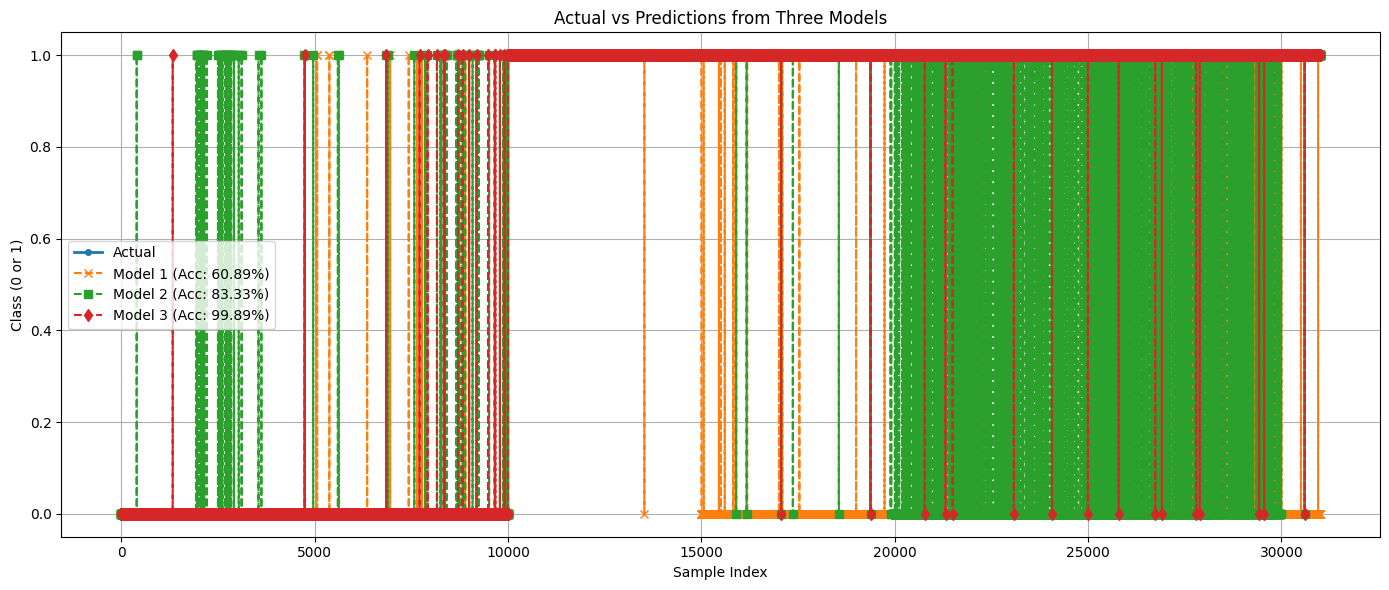

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score

def preprocess_new_data(file_path, expected_length):
    df = pd.read_csv(file_path, delimiter=',', encoding='utf-8')
    features = df.iloc[:, 2:]
    labels = df.iloc[:, 0]

    processed_features = []
    for i in range(len(features)):
        signal = features.iloc[i, :].values
        n = len(signal)
        dt = 1e-6
        signal = signal * np.hamming(n)
        fhat = np.fft.fft(signal, n)
        PSD = np.abs(fhat) ** 2 / n
        freqs = np.fft.fftfreq(n, d=dt)
        mask = (freqs > 30e3) & (freqs < 50e3)
        PSD_filtered = PSD[mask]

        # Ensure matching length
        PSD_filtered = PSD_filtered[:expected_length]
        processed_features.append(PSD_filtered)

    scaler = StandardScaler()
    processed_features = scaler.fit_transform(pd.DataFrame(processed_features))
    processed_features = processed_features.reshape(processed_features.shape[0], processed_features.shape[1], 1)

    # Encode labels
    label_encoder = LabelEncoder()
    encoded_labels = label_encoder.fit_transform(labels)

    return processed_features, encoded_labels

# --- Load models ---
model1 = load_model("/content/drive/MyDrive/DATA/SavedModels/optimized_cnn_model10000.h5")
model2 = load_model("/content/drive/MyDrive/DATA/SavedModels/optimized_cnn_model25000.h5")
model3 = load_model("/content/drive/MyDrive/DATA/SavedModels/optimized_cnn_model.h5")

# --- Preprocess data for each model based on its expected input length ---
expected_len1 = model1.input_shape[1]
expected_len2 = model2.input_shape[1]
expected_len3 = model3.input_shape[1]

x1, y_true = preprocess_new_data("/content/drive/MyDrive/DATA/DataMerge.csv", expected_len1)
x2, _      = preprocess_new_data("/content/drive/MyDrive/DATA/DataMerge.csv", expected_len2)
x3, _      = preprocess_new_data("/content/drive/MyDrive/DATA/DataMerge.csv", expected_len3)

# --- Predict ---
pred1 = (model1.predict(x1) > 0.5).astype("int32").flatten()
pred2 = (model2.predict(x2) > 0.5).astype("int32").flatten()
pred3 = (model3.predict(x3) > 0.5).astype("int32").flatten()

# --- Accuracy ---
acc1 = accuracy_score(y_true, pred1)
acc2 = accuracy_score(y_true, pred2)
acc3 = accuracy_score(y_true, pred3)

# --- Plot Actual vs Predicted ---
plt.figure(figsize=(14, 6))
plt.plot(y_true, label='Actual', linestyle='-', linewidth=2, marker='o', markersize=4)
plt.plot(pred1, label=f'Model 1 (Acc: {acc1*100:.2f}%)', linestyle='--', marker='x')
plt.plot(pred2, label=f'Model 2 (Acc: {acc2*100:.2f}%)', linestyle='--', marker='s')
plt.plot(pred3, label=f'Model 3 (Acc: {acc3*100:.2f}%)', linestyle='--', marker='d')

plt.title('Actual vs Predictions from Three Models')
plt.xlabel('Sample Index')
plt.ylabel('Class (0 or 1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


969/969 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step
969/969 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step
969/969 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step


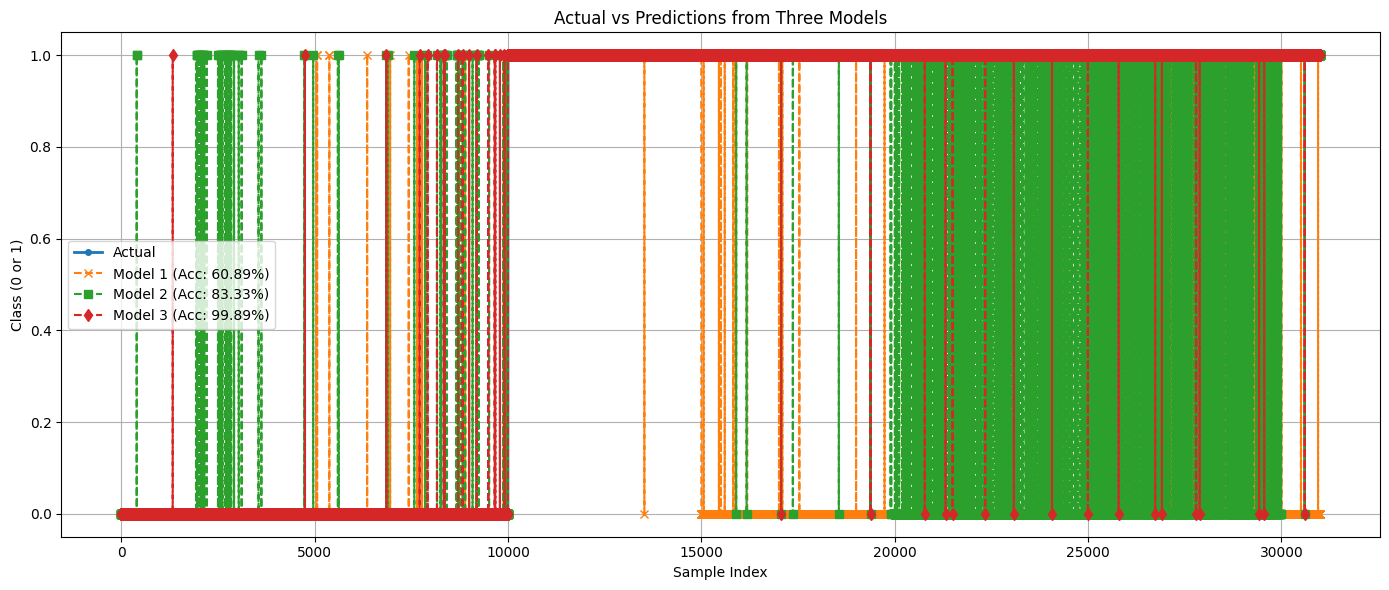

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score

def preprocess_new_data(file_path, expected_length):
    df = pd.read_csv(file_path, delimiter=',', encoding='utf-8')
    features = df.iloc[:, 2:]
    labels = df.iloc[:, 0]

    processed_features = []
    for i in range(len(features)):
        signal = features.iloc[i, :].values
        n = len(signal)
        dt = 1e-6
        signal = signal * np.hamming(n)
        fhat = np.fft.fft(signal, n)
        PSD = np.abs(fhat) ** 2 / n
        freqs = np.fft.fftfreq(n, d=dt)
        mask = (freqs > 30e3) & (freqs < 50e3)
        PSD_filtered = PSD[mask]

        # Ensure matching length
        PSD_filtered = PSD_filtered[:expected_length]
        processed_features.append(PSD_filtered)

    scaler = StandardScaler()
    processed_features = scaler.fit_transform(pd.DataFrame(processed_features))
    processed_features = processed_features.reshape(processed_features.shape[0], processed_features.shape[1], 1)

    # Encode labels
    label_encoder = LabelEncoder()
    encoded_labels = label_encoder.fit_transform(labels)

    return processed_features, encoded_labels

# --- Load models ---
model1 = load_model("/content/drive/MyDrive/DATA/SavedModels/optimized_cnn_model10000.h5")
model2 = load_model("/content/drive/MyDrive/DATA/SavedModels/optimized_cnn_model25000.h5")
model3 = load_model("/content/drive/MyDrive/DATA/SavedModels/optimized_cnn_model.h5")

# --- Preprocess data for each model based on its expected input length ---
expected_len1 = model1.input_shape[1]
expected_len2 = model2.input_shape[1]
expected_len3 = model3.input_shape[1]

x1, y_true = preprocess_new_data("/content/drive/MyDrive/DATA/DataMergeolddata.csv", expected_len1)
x2, _      = preprocess_new_data("/content/drive/MyDrive/DATA/DataMergeolddata.csv", expected_len2)
x3, _      = preprocess_new_data("/content/drive/MyDrive/DATA/DataMergeolddata.csv", expected_len3)

# --- Predict ---
pred1 = (model1.predict(x1) > 0.5).astype("int32").flatten()
pred2 = (model2.predict(x2) > 0.5).astype("int32").flatten()
pred3 = (model3.predict(x3) > 0.5).astype("int32").flatten()

# --- Accuracy ---
acc1 = accuracy_score(y_true, pred1)
acc2 = accuracy_score(y_true, pred2)
acc3 = accuracy_score(y_true, pred3)

# --- Plot Actual vs Predicted ---
plt.figure(figsize=(14, 6))
plt.plot(y_true, label='Actual', linestyle='-', linewidth=2, marker='o', markersize=4)
plt.plot(pred1, label=f'Model 1 (Acc: {acc1*100:.2f}%)', linestyle='--', marker='x')
plt.plot(pred2, label=f'Model 2 (Acc: {acc2*100:.2f}%)', linestyle='--', marker='s')
plt.plot(pred3, label=f'Model 3 (Acc: {acc3*100:.2f}%)', linestyle='--', marker='d')

plt.title('Actual vs Predictions from Three Models')
plt.xlabel('Sample Index')
plt.ylabel('Class (0 or 1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Distance (Regression Model) test

969/969 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

📊 DNN Model Evaluation:
  MAE : 15.23 cm
  RMSE: 47.15 cm
  R²  : 0.29

📊 CatBoost Model Evaluation:
  MAE : 11.29 cm
  RMSE: 21.58 cm
  R²  : 0.85


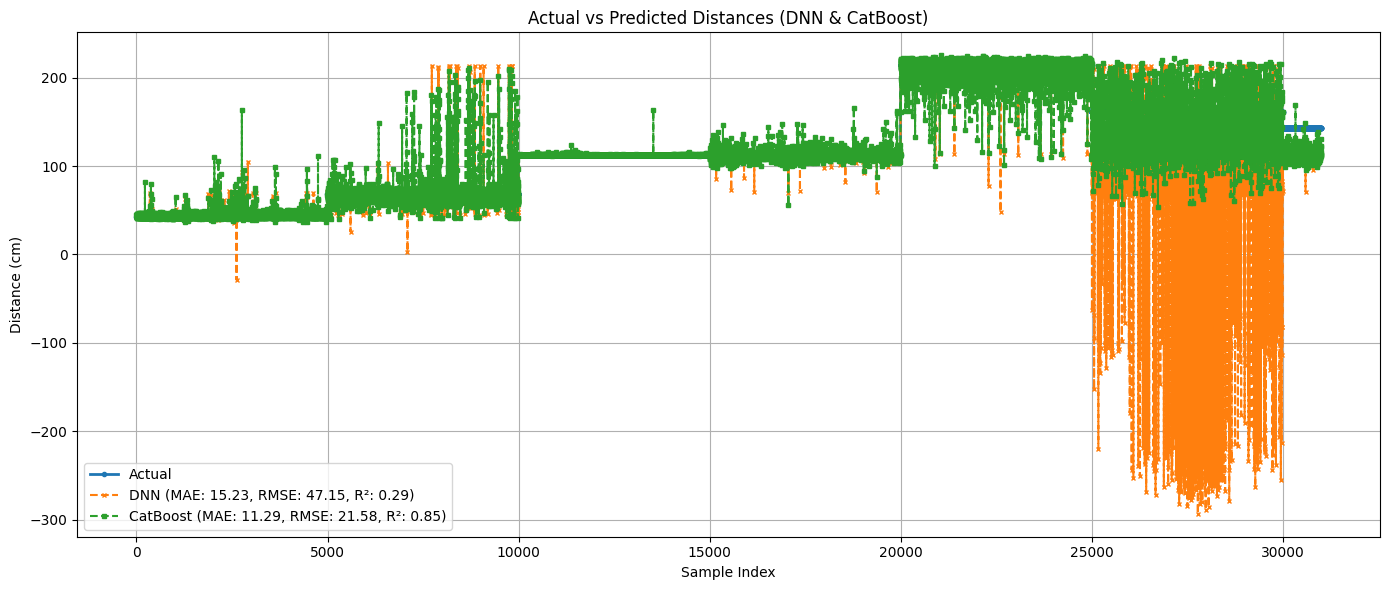

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
from catboost import CatBoostRegressor


def preprocess_new_data(file_path, scaler, selector):
    df = pd.read_csv(file_path, header=0)

    # Target and features
    y = df.iloc[:, 1].values.astype(float)
    X = df.iloc[:, 2:]

    processed_features = []

    for i in range(len(X)):
        signal = X.iloc[i, :].values.astype(float)
        n = len(signal)
        dt = 1e-6

        # Apply Hamming window
        signal_windowed = signal * np.hamming(n)

        # FFT and PSD
        fhat = np.fft.fft(signal_windowed, n)
        PSD = np.abs(fhat) ** 2 / n
        freqs = np.fft.fftfreq(n, d=dt)

        # Filter frequencies between 30kHz and 50kHz
        mask = (freqs > 30e3) & (freqs < 50e3)
        PSD_filtered = PSD[mask]

        processed_features.append(PSD_filtered)

    processed_features = pd.DataFrame(processed_features)

    # Normalize and select features
    X_scaled = scaler.transform(processed_features)
    X_selected = selector.transform(X_scaled)

    return X_selected, y


# --- Load models & transformers ---
dnn_model = load_model("/content/drive/MyDrive/DATA/SavedModels/NEWdnn_model25000.keras")
catboost_model = CatBoostRegressor()
catboost_model.load_model("/content/drive/MyDrive/DATA/SavedModels/NEWcatboost_modelonly25000.cbm")

scaler = joblib.load("/content/drive/MyDrive/DATA/SavedModels/NEWscaler25000.pkl")
selector = joblib.load("/content/drive/MyDrive/DATA/SavedModels/NEWselector25000.pkl")

# --- Preprocess test data ---
x_test, y_true = preprocess_new_data("/content/drive/MyDrive/DATA/DataMergeolddata.csv", scaler, selector)

# --- Predict ---
y_pred_dnn = dnn_model.predict(x_test).flatten()
y_pred_cat = catboost_model.predict(x_test)

# --- Evaluate ---
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n📊 {name} Evaluation:")
    print(f"  MAE : {mae:.2f} cm")
    print(f"  RMSE: {rmse:.2f} cm")
    print(f"  R²  : {r2:.2f}")

    return mae, rmse, r2


mae_dnn, rmse_dnn, r2_dnn = evaluate_model("DNN Model", y_true, y_pred_dnn)
mae_cat, rmse_cat, r2_cat = evaluate_model("CatBoost Model", y_true, y_pred_cat)

# --- Plot ---
plt.figure(figsize=(14, 6))
plt.plot(y_true, label='Actual', linestyle='-', linewidth=2, marker='o', markersize=3)
plt.plot(y_pred_dnn, label=f'DNN (MAE: {mae_dnn:.2f}, RMSE: {rmse_dnn:.2f}, R²: {r2_dnn:.2f})', linestyle='--', marker='x', markersize=3)
plt.plot(y_pred_cat, label=f'CatBoost (MAE: {mae_cat:.2f}, RMSE: {rmse_cat:.2f}, R²: {r2_cat:.2f})', linestyle='--', marker='s', markersize=3)

plt.title('Actual vs Predicted Distances (DNN & CatBoost)')
plt.xlabel('Sample Index')
plt.ylabel('Distance (cm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
